# Cross-Validation Analysis

This notebook implements K-fold cross-validation to provide more robust performance estimates.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from sklearn.model_selection import KFold
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

DATA_DIR = Path('../data/flowers')
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

Using device: cpu


In [2]:
# Prepare dataset with transformations
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

# Load full dataset
full_dataset = ImageFolder(root=DATA_DIR / 'train', transform=train_transform)
print(f"Total training samples: {len(full_dataset)}")
print(f"Number of classes: {len(full_dataset.classes)}")

Total training samples: 1020
Number of classes: 102


In [3]:
# Setup K-fold cross-validation
k_folds = 5
kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# Store results
fold_results = []

def create_model():
    """Create a fresh model for each fold"""
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Linear(2048, 102)
    model = model.to(device)
    return model

def train_fold(train_indices, val_indices, fold_num):
    """Train model on one fold"""
    # Create data loaders for this fold
    train_sampler = torch.utils.data.SubsetRandomSampler(train_indices)
    val_sampler = torch.utils.data.SubsetRandomSampler(val_indices)
    
    # Use different transform for validation
    train_loader = torch.utils.data.DataLoader(
        full_dataset, batch_size=32, sampler=train_sampler, num_workers=4
    )
    
    # Create validation dataset with validation transform
    val_dataset = ImageFolder(root=DATA_DIR / 'train', transform=val_transform)
    val_loader = torch.utils.data.DataLoader(
        val_dataset, batch_size=32, sampler=val_sampler, num_workers=4
    )
    
    # Create model
    model = create_model()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
    
    # Training
    num_epochs = 5
    best_val_acc = 0
    
    for epoch in range(num_epochs):
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
        # Validation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        
        val_acc = correct / total
        best_val_acc = max(best_val_acc, val_acc)
        
        if (epoch + 1) % 2 == 0:
            print(f"  Fold {fold_num}, Epoch {epoch+1}/{num_epochs}: Val Acc = {val_acc:.4f}")
    
    return best_val_acc

# Run cross-validation
print(f"Starting {k_folds}-fold cross-validation...")
for fold, (train_indices, val_indices) in enumerate(kfold.split(full_dataset)):
    print(f"\nFold {fold + 1}/{k_folds}")
    print("-" * 40)
    val_acc = train_fold(train_indices, val_indices, fold + 1)
    fold_results.append(val_acc)
    print(f"Fold {fold + 1} best validation accuracy: {val_acc:.4f}")

Starting 5-fold cross-validation...

Fold 1/5
----------------------------------------
  Fold 1, Epoch 2/5: Val Acc = 0.3775
  Fold 1, Epoch 4/5: Val Acc = 0.6275
Fold 1 best validation accuracy: 0.6716

Fold 2/5
----------------------------------------
  Fold 2, Epoch 2/5: Val Acc = 0.3627
  Fold 2, Epoch 4/5: Val Acc = 0.6667
Fold 2 best validation accuracy: 0.7157

Fold 3/5
----------------------------------------
  Fold 3, Epoch 2/5: Val Acc = 0.5098
  Fold 3, Epoch 4/5: Val Acc = 0.6618
Fold 3 best validation accuracy: 0.7500

Fold 4/5
----------------------------------------
  Fold 4, Epoch 2/5: Val Acc = 0.4020
  Fold 4, Epoch 4/5: Val Acc = 0.6765
Fold 4 best validation accuracy: 0.6912

Fold 5/5
----------------------------------------
  Fold 5, Epoch 2/5: Val Acc = 0.3088
  Fold 5, Epoch 4/5: Val Acc = 0.7010
Fold 5 best validation accuracy: 0.7304


In [4]:
# Analyze cross-validation results
fold_results_array = np.array(fold_results)

print("=" * 60)
print("CROSS-VALIDATION RESULTS")
print("=" * 60)
print(f"\nIndividual fold accuracies:")
for i, acc in enumerate(fold_results):
    print(f"  Fold {i+1}: {acc:.4f}")

print(f"\nMean accuracy: {fold_results_array.mean():.4f}")
print(f"Standard deviation: {fold_results_array.std():.4f}")
print(f"Minimum accuracy: {fold_results_array.min():.4f}")
print(f"Maximum accuracy: {fold_results_array.max():.4f}")
print(f"95% CI: [{fold_results_array.mean() - 1.96*fold_results_array.std()/np.sqrt(k_folds):.4f}, "
      f"{fold_results_array.mean() + 1.96*fold_results_array.std()/np.sqrt(k_folds):.4f}]")
print("=" * 60)

CROSS-VALIDATION RESULTS

Individual fold accuracies:
  Fold 1: 0.6716
  Fold 2: 0.7157
  Fold 3: 0.7500
  Fold 4: 0.6912
  Fold 5: 0.7304

Mean accuracy: 0.7118
Standard deviation: 0.0278
Minimum accuracy: 0.6716
Maximum accuracy: 0.7500
95% CI: [0.6874, 0.7361]


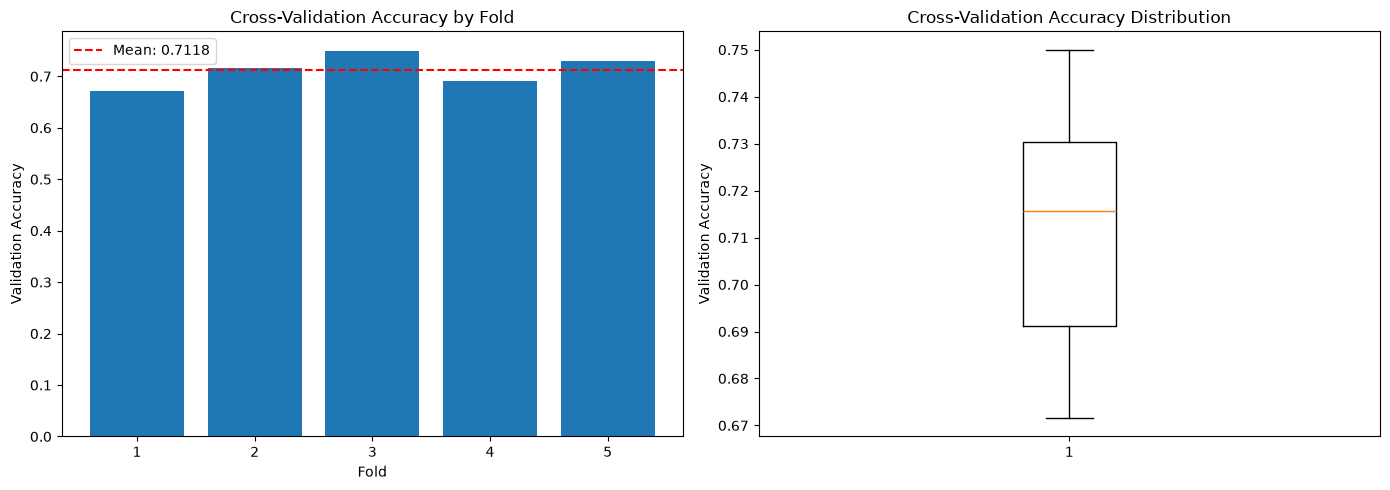

In [5]:
# Visualize results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
ax1.bar(range(1, k_folds+1), fold_results)
ax1.axhline(y=fold_results_array.mean(), color='r', linestyle='--', label=f'Mean: {fold_results_array.mean():.4f}')
ax1.set_xlabel('Fold')
ax1.set_ylabel('Validation Accuracy')
ax1.set_title('Cross-Validation Accuracy by Fold')
ax1.legend()

# Box plot
ax2.boxplot(fold_results)
ax2.set_ylabel('Validation Accuracy')
ax2.set_title('Cross-Validation Accuracy Distribution')

plt.tight_layout()
plt.show()